# visualize_result: outputs/ 配下の全実験結果の横断可視化

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yryo1005/TicTacToe_Reinforcement_Learning_training/blob/main/visualize_result.ipynb)

本ノートブックは，`outputs/`ディレクトリを再帰的に走査し，同一条件(実験名・アルゴリズム名・
ハイパーパラメータの組)における全シードの最終評価結果(`eval.json`)から平均と標準偏差を計算して
可視化する，リポジトリ共通の汎用ツールである．
`ex001_random_baseline.ipynb`〜`ex006_comparison_and_play.ipynb`を実行した後に本ノートブックを
実行すると，それらが`outputs/`に保存した結果を横断的に一覧・比較できる．比較したい条件は
下記`TARGET_CONDITIONS`で選択・指定できる．


必要なライブラリをインポートし，グラフの日本語フォントを設定する．

In [1]:
import os
import json
import subprocess
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if "IPAexGothic" not in {f.name for f in fm.fontManager.ttflist}:
    try:
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-ipaexfont-gothic"],
            check=False, capture_output=True,
        )
        fm.fontManager.addfont(
            "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf"
        )
    except Exception:
        pass
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False

OUTPUTS_ROOT = "outputs"
COMPARISON_DIR = os.path.join(OUTPUTS_ROOT, "_comparison")


`outputs/`を再帰的に走査して条件(実験名・アルゴリズム名・ハイパーパラメータ)ごとに整理する`scan_outputs`と，シード間の平均・標準偏差を計算する`summarize_by_condition`を定義する．

In [2]:
def scan_outputs(root: str = OUTPUTS_ROOT) -> list:
    """
    outputs/ディレクトリを再帰的に走査し, "seed_*"という名前のディレクトリのうち
    eval.json(evaluate関数による最終評価結果)を持つものを全て発見し,
    実験名・アルゴリズム名・ハイパーパラメータ・シードの情報とともに一覧化する.

    引数:
        root (str): 走査を開始するディレクトリのパス.
    戻り値:
        list[dict]: 各実行(1つのseedディレクトリ)についての情報を持つ辞書のリスト.
            各辞書は "path"(ディレクトリパス), "condition_key"(実験名/アルゴリズム名/
            ハイパーパラメータを"/"で連結したもの), "seed", "eval"(勝率等), "config"(あれば)を持つ.
    """
    # ディレクトリツリー全体を走査し, "seed_*"という名前で, かつ最終評価(eval.json)を
    # 持つディレクトリだけを1つの実行結果として拾い上げる.
    records = []
    if not os.path.isdir(root):
        return records
    for dirpath, _dirnames, filenames in os.walk(root):
        name = os.path.basename(dirpath)
        if not name.startswith("seed_") or "eval.json" not in filenames:
            continue
        rel_parts = os.path.relpath(dirpath, root).split(os.sep)
        condition_key = "/".join(rel_parts[:-1])
        with open(os.path.join(dirpath, "eval.json")) as f:
            eval_result = json.load(f)
        config = None
        config_path = os.path.join(dirpath, "config.json")
        if os.path.exists(config_path):
            with open(config_path) as f:
                config = json.load(f)
        records.append({
            "path": dirpath,
            "condition_key": condition_key,
            "seed": int(name.split("_")[1]),
            "eval": eval_result,
            "config": config,
        })
    return records


def summarize_by_condition(records: list) -> dict:
    """
    scan_outputsで得られたレコードを条件(condition_key)ごとにまとめ,
    複数シードにわたる勝率・引き分け率・敗率の平均と標準偏差を計算する.

    引数:
        records (list[dict]): scan_outputsの戻り値.
    戻り値:
        dict[str, dict]: 条件名 -> {"n_seeds", "win_mean", "win_std", "draw_mean", "draw_std",
            "lose_mean", "lose_std"} の辞書.
    """
    grouped = defaultdict(list)
    for r in records:
        grouped[r["condition_key"]].append(r)

    summary = {}
    for key, rs in grouped.items():
        wins = [r["eval"]["win_rate"] for r in rs]
        draws = [r["eval"]["draw_rate"] for r in rs]
        loses = [r["eval"]["lose_rate"] for r in rs]
        summary[key] = {
            "n_seeds": len(rs),
            "win_mean": float(np.mean(wins)), "win_std": float(np.std(wins)),
            "draw_mean": float(np.mean(draws)), "draw_std": float(np.std(draws)),
            "lose_mean": float(np.mean(loses)), "lose_std": float(np.std(loses)),
        }
    return summary


## 条件の走査と選択

発見された全条件とそのシード平均勝率を一覧表示し，可視化対象の条件を選択する．

In [3]:
records = scan_outputs()
summary = summarize_by_condition(records)

print(f"発見された条件数: {len(summary)}")
for key, s in sorted(summary.items()):
    print(f"  {key}  (n_seeds={s['n_seeds']}): win={s['win_mean']:.3f}±{s['win_std']:.3f}")

# 比較したい条件をここで指定する(空リストの場合は発見された全条件を対象とする).
# 部分一致で条件を絞り込みたい場合は, 条件名に含まれる文字列のリストにしてもよい.
TARGET_CONDITIONS = []  # 例: ["ex002_tictactoe_dp/PolicyIteration", "ex005_tictactoe_td/QLearning"]

if TARGET_CONDITIONS:
    selected_keys = [
        key for key in summary
        if any(target in key for target in TARGET_CONDITIONS)
    ]
else:
    selected_keys = list(summary.keys())
selected_keys = sorted(selected_keys)
print(f"\n可視化対象: {len(selected_keys)}件")


発見された条件数: 5
  ex001_tictactoe_baseline/RandomAgent  (n_seeds=3): win=0.583±0.020
  ex002_tictactoe_dp/PolicyIteration/gamma0.95_theta0.0001  (n_seeds=3): win=0.995±0.001
  ex003_tictactoe_dp/ValueIteration/gamma0.95_theta0.0001  (n_seeds=3): win=0.995±0.001
  ex004_tictactoe_mc/MonteCarloControl/gamma0.95_epsilon0.1  (n_seeds=3): win=0.984±0.006
  ex005_tictactoe_td/QLearning/gamma0.95_alpha0.1_epsilon0.1  (n_seeds=3): win=0.954±0.008

可視化対象: 5件


## 可視化

選択した条件の勝率を棒グラフで比較し，集計結果を`outputs/_comparison/`に保存する．

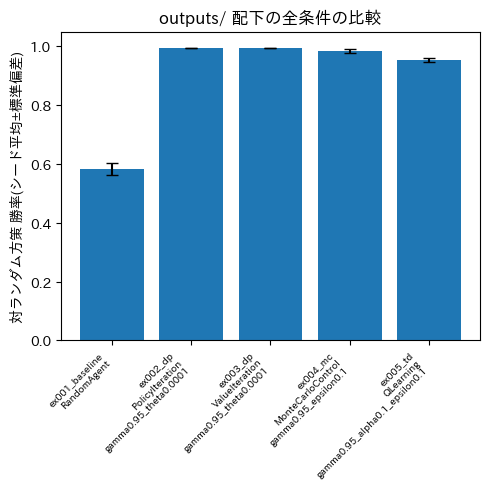

集計結果を outputs/_comparison/summary.json に保存しました.


In [4]:
os.makedirs(COMPARISON_DIR, exist_ok=True)

win_means = [summary[k]["win_mean"] for k in selected_keys]
win_stds = [summary[k]["win_std"] for k in selected_keys]
short_labels = [k.replace("_tictactoe", "").replace("/", "\n") for k in selected_keys]

fig, ax = plt.subplots(figsize=(5, 5))
x = np.arange(len(selected_keys))
ax.bar(x, win_means, yerr=win_stds, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("対ランダム方策 勝率(シード平均±標準偏差)")
ax.set_ylim(0, 1.05)
ax.set_title("outputs/ 配下の全条件の比較")
fig.tight_layout()
fig.savefig(os.path.join(COMPARISON_DIR, "win_rate_by_condition.png"), dpi=150)
plt.show()

with open(os.path.join(COMPARISON_DIR, "summary.json"), "w") as f:
    json.dump({k: summary[k] for k in selected_keys}, f, indent=4, ensure_ascii=False)
print(f"集計結果を {os.path.join(COMPARISON_DIR, 'summary.json')} に保存しました.")


## 使い方

1. `ex001_random_baseline.ipynb`〜`ex006_comparison_and_play.ipynb`を実行し，`outputs/`以下に結果を蓄積する．
2. 本ノートブックを実行すると，発見された全条件(実験名/アルゴリズム名/ハイパーパラメータ)とそのシード平均勝率が一覧表示される．
3. 特定の条件のみを比較したい場合は，`TARGET_CONDITIONS`に条件名(または条件名に含まれる部分文字列)のリストを指定して再実行する．
4. 比較結果の棒グラフと集計値は`outputs/_comparison/`に保存される．
